# Exercise 1

a)

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$


$$
\boldsymbol{a}^T\boldsymbol{x} = [a_1 x_1  \space a_2 x_2 \space .... \space a_n x_n]
$$

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = {\nabla}_x (a^T x) = [ \frac{\partial (\boldsymbol{a_1}\boldsymbol{x_1})}{\partial \boldsymbol{x}} \space \frac{\partial (\boldsymbol{a_2}\boldsymbol{x_2})}{\partial \boldsymbol{x}} \space ..... \space \frac{\partial (\boldsymbol{a_n}\boldsymbol{x_n})}{\partial \boldsymbol{x}}]
$$

$$
= [a_1 \space a_2 \space ..... \space a_n] = a^T
$$

b)

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

Her er $\boldsymbol{a}$ en vektor med lengde n, og $\boldsymbol{A}$ er en matrise med dimensjoner n x n.
Dette gjør at vi kan skrive $\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a}$ som en sum slik:

$$
\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a} = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} a_{i} b_{ij} a_{j}
$$
Kallar elementene i $\boldsymbol{A}$ for $b_{ij}$
$\\$
Hvis vi tar den deriverte med hensyn på element $a_k$ i $\boldsymbol{a}$ kan vi bruke produktregelen:

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial a_k} = \sum_{i=0}^{n-1} a_{i} b_{ik} + \sum_{j=0}^{n-1} a_{j} b_{kj}
$$
der k = 0, 1, 2, ....., n-1

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T \boldsymbol{A} + \boldsymbol{a}^T \boldsymbol{A}^T = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right)
$$

c)

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A}
$$

Definerer en funksjon $f(\boldsymbol{s})$ og en matrise $\boldsymbol{w}$
$$
f(\boldsymbol{s}) = (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})^T (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}) = \sum_{i=0}^{n-1} (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})^2
$$
$$
\boldsymbol{w} = \boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}
$$
=>
$$
f(\boldsymbol{s}) = \boldsymbol{w}^T \boldsymbol{w}
$$

$$
\frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s}} = 2 \boldsymbol{w}^T \frac{\partial \boldsymbol{w}}{\partial \boldsymbol{s}}
$$

Bruker at:
$$
\frac{\partial \boldsymbol{w}}{\partial \boldsymbol{s}} = - \boldsymbol{A}
$$
=>
$$
\frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s}} = - 2 (\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})^T A
$$

Finne andrederiverte:
$\\$
Begynner med å skrive om den deriverte med hensyn på $\boldsymbol{s}^T$

$$
\frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s}^T} = - 2 \boldsymbol{A}^T(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})
$$
$$
\frac{\partial }{\partial \boldsymbol{s}} \frac{\partial f(\boldsymbol{s})}{\partial \boldsymbol{s^T}} = \frac{\partial }{\partial \boldsymbol{s}} [- 2 \boldsymbol{A}^T(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s})] = 2 \boldsymbol{A}^T \boldsymbol{A}
$$

Der
$$
\boldsymbol{A}^T \boldsymbol{A} = \boldsymbol{H}
$$
Er Hessian matrisen $\boldsymbol{H}$

# Exercise 2

1.

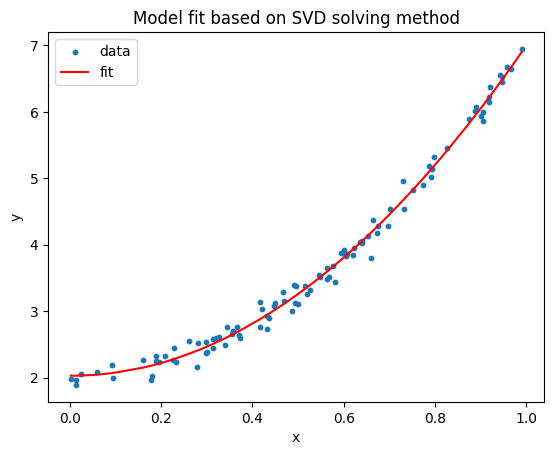

In [69]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

X = np.zeros((100, 3))

for j in range(3):
    X[:,j] = x.flatten()**j

theta = np.linalg.lstsq(X, y, rcond=None)[0] # Using the SVD method
y_tilde = X @ theta

x_sorted_idx = np.argsort(x.flatten())
plt.scatter(x, y, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], y_tilde.flatten()[x_sorted_idx], color="red", label="fit")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title(r'Model fit based on SVD solving method')
plt.show()

2.

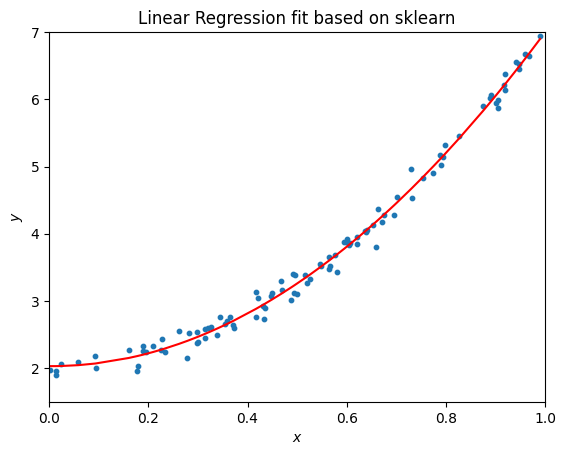

In [68]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X,y)
y_tilde_sklearn = linreg.predict(X)


plt.scatter(x, y, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], y_tilde_sklearn.flatten()[x_sorted_idx],'r-')
plt.axis([0.0,1.0,1.5, 7.0])
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Linear Regression fit based on sklearn')
plt.show()

3.

In [4]:
from sklearn.metrics import mean_squared_error, r2_score

# The mean squared error    
print("Mean squared error using own function:", mean_squared_error(y, y_tilde))                           
print("Mean squared error using sklearn:", mean_squared_error(y, y_tilde_sklearn))

# Explained variance score: 1 is perfect prediction   
print('R^2 score using own function:', r2_score(y, y_tilde))                              
print('R^2 score using sklearn:', r2_score(y, y_tilde_sklearn))

Mean squared error using own function: 0.013728156746263008
Mean squared error using sklearn: 0.013728156746263003
R^2 score using own function: 0.9928732429893427
R^2 score using sklearn: 0.9928732429893427


The MSE and R^2 score was the same for the SVD and Sklearn method. $\\$
The MSE tells us how close the predicted outputs are from the actual outputs y, while the R^2 score function gives us the proportion of variance in the dependent variables that is caused by the independant variables - 100% (1) is a perfect match. 
$\\$
While increasing the noise the MSE is increased, and the R^2 score proportion is decreased. This means that increased noise cause the model to be less accurate. 

# Exercise 3

1.

In [46]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

n = 100
x3 = np.linspace(-3, 3, n).reshape(-1, 1)
y3 = np.exp(-x3**2) + 1.5 * np.exp(-(x3 - 2)**2) + rng.normal(0, 0.1, x3.shape)

X3 = np.zeros((n,6)) # fifth order polynomial

for j in range(6):
    X3[:,j] = x3.flatten()**j


X3_train, X3_test, y3_train, y3_test, x3_train, x3_test = train_test_split(X3, y3, x3, test_size=0.33, random_state=42)



2.

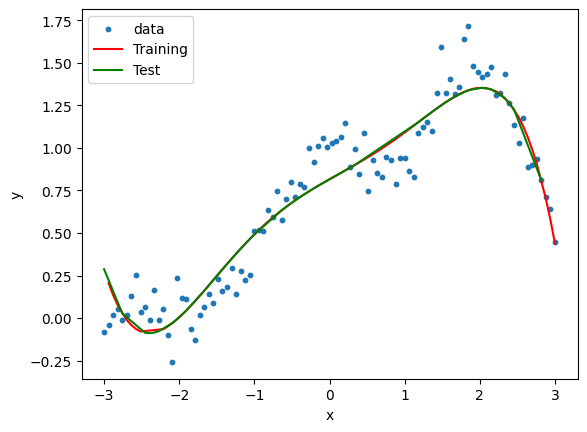

In [47]:
from sklearn.linear_model import LinearRegression

OLS = LinearRegression()
OLS.fit(X3_train,y3_train)

y_tilde_train = OLS.predict(X3_train) # fitting the model to training data
y_tilde_test = OLS.predict(X3_test) # fitting the model to test data

# Need to sort elements in order from low to high values to prevent zigzag model-graphs in plot. 
# Argsort gives the indices that gives this order, which is then used to sort the elements in the array  
x3_train_idx = np.argsort(x3_train.flatten()) # sorted indexes based on training input x 
x3_test_idx = np.argsort(x3_test.flatten()) # sorted indexes based on test input x

plt.scatter(x3, y3, s=10, label="data") # plottet data as points
plt.plot(x3_train.flatten()[x3_train_idx], y_tilde_train.flatten()[x3_train_idx], color="red", label="Training")
plt.plot(x3_test.flatten()[x3_test_idx], y_tilde_test.flatten()[x3_test_idx], color="green", label="Test")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [48]:
from sklearn.metrics import mean_squared_error

print("Mean squared error for training data:", mean_squared_error(y3_train, y_tilde_train))
print("Mean squared error for test data:", mean_squared_error(y3_test, y_tilde_test))

Mean squared error for training data: 0.02314351485631477
Mean squared error for test data: 0.02482399036080154


3.

Using method from week 35 tuesday slides:

In [49]:
import numpy as np

def MSE(y_data, y_model):
    return np.mean((y_data - y_model) ** 2)

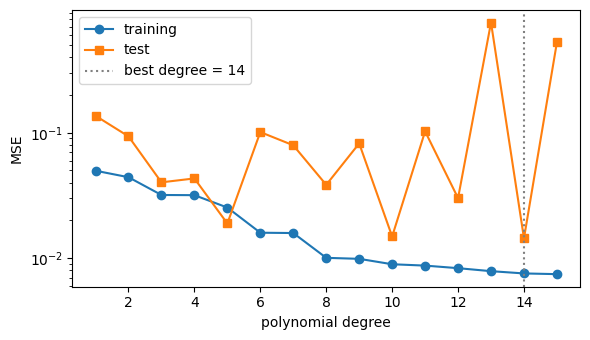

best OLS test MSE 0.01442 at degree 14


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

n = 100
x3 = np.linspace(-3, 3, n).reshape(-1, 1)
y3 = np.exp(-x3**2) + 1.5 * np.exp(-(x3 - 2)**2) + rng.normal(0, 0.1, x3.shape)

x_train, x_test, y_train, y_test = train_test_split(x3, y3, test_size=0.3,random_state=2026) # splitting data

# 1. OLS: training and test MSE against polynomial degree
degrees = range(1, 16)
mse_train, mse_test = [], []
for d in degrees: # runs through degrees 1-15
    # np.vander creates a matrix where the columns are the power of the input vector, increasing power in this case
    Xtr = np.vander(x_train.flatten(), d + 1, increasing=True) # d + 1 is the number of columns
    Xte = np.vander(x_test.flatten(),  d + 1, increasing=True)

    theta = np.linalg.lstsq(Xtr, y_train, rcond=None)[0] # gives the theta parameters based on given polynomial degree in the design matrix
    mse_train.append(MSE(y_train, Xtr @ theta)) # inputs in MSE (known y data, predicted y datas based on model)
    mse_test.append(MSE(y_test,  Xte @ theta))

best_d = degrees[int(np.argmin(mse_test))] # finds the index = degree that has the lowest MSE in test data
plt.figure(figsize=(6, 3.5))
plt.plot(degrees, mse_train, "o-", label="training") # plotting mean square error over degrees
plt.plot(degrees, mse_test, "s-", label="test")
plt.axvline(best_d, color="gray", ls=":", label=f"best degree = {best_d}")
plt.xlabel("polynomial degree"); plt.ylabel("MSE"); plt.yscale("log"); plt.legend()
plt.tight_layout(); plt.show()
print(f"best OLS test MSE {min(mse_test):.5f} at degree {best_d}")

We see that the MSE of the training data decreases as polynomial degree is increased. As the polynomial degree increases, the model gets more complex and eventually starts adapting to the noise - known as overfitting. This is evident in the test data, as the overfitted model is no longer suited when used on other data. $\\$
For low polynomial degrees the MSE is also high for both training and tesing data. This comes from the low degree polynomials not being complex enough to describe the dataset, making the MSE higher. 

# Exercise 4

Using the method from the tuesday week 35 slides for the 15 degree polynomial

1.

In [64]:
# defining ridge through SVD solver
def ridge_svd(X, y, lmbda):
    """Ridge through the SVD: sum_i sigma_i/(sigma_i^2 + lambda) (u_i . y) v_i.

    Solves min ||y - X theta||^2 + lambda ||theta||^2  (no 1/n factor).
    """
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (s / (s**2 + lmbda) * (U.T @ y))


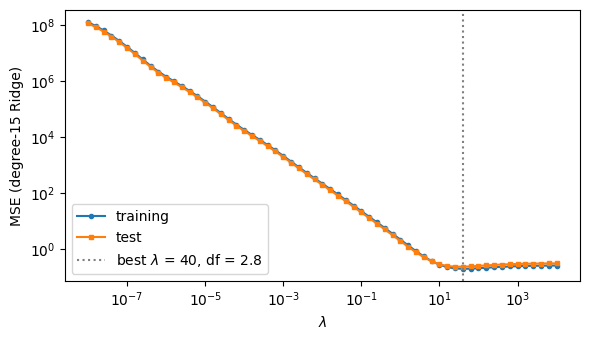

best Ridge test MSE 0.23817 at lambda 39.8 (effective dof 2.79; best OLS degree above was 14)


In [ ]:
d = 15
Xtr = np.vander(x_train.flatten(), d + 1, increasing=True) # construct a design matrix based on input x
Xte = np.vander(x_test.flatten(),  d + 1, increasing=True)
# standardise (fit on training data only!), centre y
mu, sd = Xtr[:, 1:].mean(axis=0), Xtr[:, 1:].std(axis=0) # define mean and standard deviation based on training data
Xtr_s, Xte_s = (Xtr[:, 1:] - mu) / sd, (Xte[:, 1:] - mu) / sd # standardize the design matrix, exclude intercept
ym = y_train.mean()

lambdas = np.logspace(-8, 4, 61)
mse_tr_r, mse_te_r, dfs = [], [], []
s = np.linalg.svd(Xtr_s, compute_uv=False) # computes the singular values (sigma1, sigma2...) for the design matrix based on training data
for l in lambdas:
    theta = ridge_svd(Xtr_s, y_train - ym, l) # Finds theta for a given lambda, sends inn centered y training data  
    mse_tr_r.append(MSE(y_train, ym + Xtr_s @ theta))
    mse_te_r.append(MSE(y_test,  ym + Xte_s @ theta))
    dfs.append(np.sum(s**2 / (s**2 + l)))          # effective degrees of freedom: how many parameters the model effectivly is using

best = int(np.argmin(mse_te_r)) # finds the index where the MSE is lowest for testing data - the same as degree corresponding to lowest MSE
plt.figure(figsize=(6, 3.5))
plt.plot(lambdas, mse_tr_r, "o-", ms=3, label="training")
plt.plot(lambdas, mse_te_r, "s-", ms=3, label="test")
plt.axvline(lambdas[best], color="gray", ls=":",
            label=rf"best $\lambda$ = {lambdas[best]:.2g}, df = {dfs[best]:.1f}")
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"$\lambda$"); plt.ylabel("MSE (degree-15 Ridge)"); plt.legend()
plt.tight_layout(); plt.show()
print(f"best Ridge test MSE {mse_te_r[best]:.5f} at lambda {lambdas[best]:.3g} "
      f"(effective dof {dfs[best]:.2f}; best OLS degree above was {best_d})")

The plot shows a very slight U-shape, with a minimum at the best lambda.
However, the MSE decreases significantly before reaching the minimum, and the increase after seems to be converging for high lambda. $\\$
This suggests that the low value lambdas, which represents low bias and high variance, are at first significantly affected by overfitting. This makes sense as the penalty term in the ridge model has barely any impact for small lambda, meaning the model is approximately an OLS fit with a 15 degree polynomial. Furthermore, the effect of overfitting decreases as lambda increase, which we should expect since the penalty term in the ridge model increasingly dominates as lambda increase.  $\\$
$\\$
On the right hand side of the lambda minimum, the increase is not as drastic as the decrease is on the left hand side. A high lambda value forces coefficients toward zero, including the coefficients that are carrying information matching the dataset. Since y was centered before fitting and the intercept was excluded from the penalty, the prediction converge towards the mean as the coefficients is forced toward zero. 

2.

Comparing the best test MSE using Ridge:

In [61]:
print(f"best Ridge test MSE {mse_te_r[best]:.5f}")

best Ridge test MSE 0.23817


With the best MSE found in exercise 3.3:

In [62]:
print(f"best OLS test MSE {min(mse_test):.5f}")

best OLS test MSE 0.01442


We see that the MSE using OLS and varying polynomial degree is in an order of 10 magnitudes smaller, suggesting this method gives us the finer control. 

3.

Checking training MSE values for the Ridge method:

In [66]:
mse_tr_r = np.array(mse_tr_r)
print(np.all(np.diff(mse_tr_r) >= 0))  # True if monotonically non-decreasing

False


Here there is obviously a problem since the training MSE is not monotonically increasing. This should be the case as the penalty term is weigthed increasingly as lambda increases - resulting in loss of data in the coefficients theta that contributes significantly to the best model fit. 